## First Implementation of the TFT with only Macro Variables

### Inspecting & Importing Data

In [1]:
import pytorch_forecasting
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays
# different than original example
import lightning.pytorch as pl
import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
# using weights and biases to visualise training
from lightning.pytorch.loggers import WandbLogger
wandb_logger = WandbLogger(project="tft", name="tft-longformat")

/Users/minna/Code/FS26/AML/aml2026-group-3/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
qrtly_path = '/Users/minna/Code/FS26/AML/aml2026-group-3/data/macro-vars-quarterly.csv'
df_quartly = pd.read_csv(qrtly_path)
df_quartly = df_quartly.rename(columns = {'Unnamed: 0':'date'})
df_quartly['date'] = pd.to_datetime(df_quartly['date'])
print(df_quartly.tail(10))

          date        GDP
310 2023-07-01  28074.846
311 2023-10-01  28424.722
312 2024-01-01  28708.161
313 2024-04-01  29147.044
314 2024-07-01  29511.664
315 2024-10-01  29825.182
316 2025-01-01  30042.113
317 2025-04-01  30485.729
318 2025-07-01  31098.027
319 2025-10-01  31422.526


In [25]:
# os.getcwd()
monthly_path = '/Users/minna/Code/FS26/AML/aml2026-group-3/data/macro-vars-monthly.csv'
df_monthly = pd.read_csv(monthly_path)
df_monthly = df_monthly.rename(columns = {'Unnamed: 0':'date'})
df_monthly['date'] = pd.to_datetime(df_monthly['date'])
# print(df_monthly.tail(10))

# merge 
df = pd.merge(df_monthly, df_quartly, on='date', how='left')
# here you can see gdp has a stronger publication lag than the motnhly vars
print(df.tail(10))


           date      CPI    PCEPI    PAYEMS  JTSJOL  UMCSENT    INDPRO  \
1277 2025-06-01  321.435  126.743  158478.0  7204.0     60.7  101.4785   
1278 2025-07-01  322.169  126.960  158542.0  7089.0     61.7  101.8940   
1279 2025-08-01  323.291  127.293  158472.0  6919.0     58.2  101.6247   
1280 2025-09-01  324.245  127.625  158548.0  7169.0     55.1  101.6680   
1281 2025-10-01      NaN  127.871  158408.0  7170.0     53.6  101.2195   
1282 2025-11-01  325.063  128.152  158449.0  6846.0     51.0  101.0810   
1283 2025-12-01  326.031  128.576  158432.0  6550.0     52.9  101.6113   
1284 2026-01-01  326.588  128.965  158592.0  7240.0     56.4  101.5954   
1285 2026-02-01  327.460  129.449  158459.0  6882.0     56.6  102.3440   
1286 2026-03-01  330.293      NaN  158637.0     NaN      NaN  101.7898   

      UNRATE        GDP  
1277     4.1        NaN  
1278     4.3  31098.027  
1279     4.3        NaN  
1280     4.4        NaN  
1281     NaN  31422.526  
1282     4.5        NaN  
128

In [26]:
# select only the 3 vars with the longest history to avoid NaN issues
df = df[["date", "CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]]

# drop rows where any core variable is NaN (restricts to common date range)
df = df.dropna(subset=["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]).reset_index(drop=True)
print(f"Date range after dropping NAs: {df['date'].min()} to {df['date'].max()}, {len(df)} rows")

Date range after dropping NAs: 1948-01-01 00:00:00 to 2025-07-01 00:00:00, 311 rows


In [27]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    311 non-null    datetime64[us]
 1   CPI     311 non-null    float64       
 2   PAYEMS  311 non-null    float64       
 3   INDPRO  311 non-null    float64       
 4   UNRATE  311 non-null    float64       
 5   GDP     311 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 14.7 KB
None


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

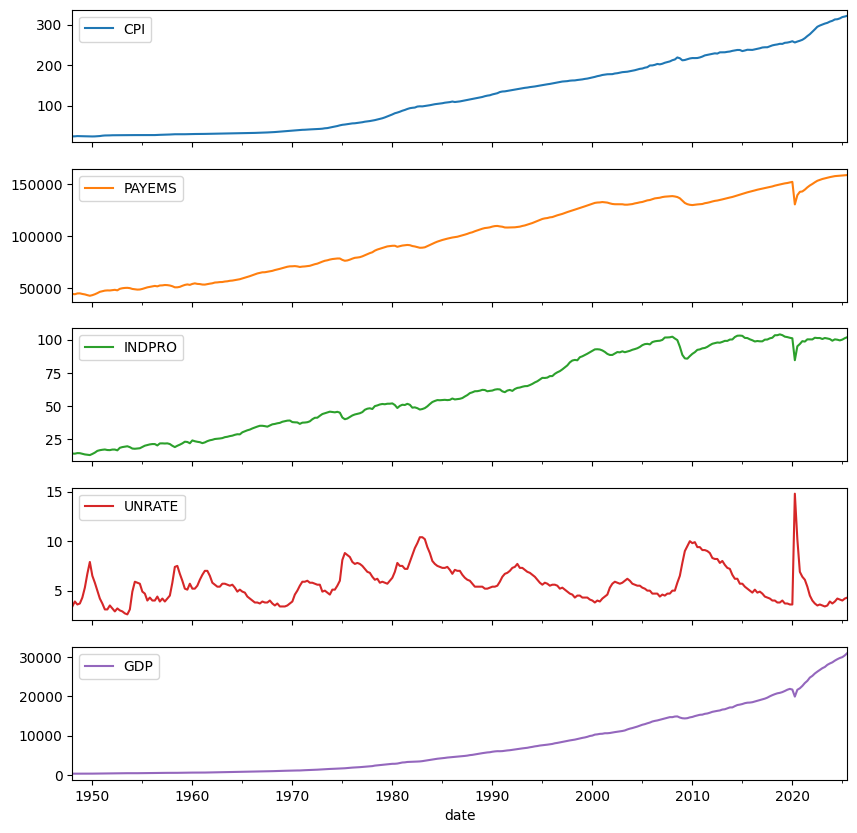

In [29]:
# basic plot to inspect length
df.plot(x='date', y=['CPI', 'PAYEMS','INDPRO', 'UNRATE', 'GDP'], subplots=True, figsize=(10, 10))

#### Meaning of Variables:

**CPI** -> Consumer Price Index 
<!-- **PCEPI** -> Personal Consumption Expenditures Price Index  -->
**PAYEMS** -> Total Nonfarm Payrolls
<!-- **JTSJOL** -> Job Openings: Total Nonfarm (non-farm workers)
**UMCSENT** -> University of Michigan Sentiment Index -->
**INDPRO** -> Industrial Production Index

**UNRATE** -> Unemployment Rate

### Implementing TFT

**Info on Model**, based on the following paper: [Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting](https://arxiv.org/abs/1912.09363)


The TFT should handle single or multiple targets and a whole lot of different covariates such as:

- *static covariates*: these are the ones that do not change through the course of the timeseries. In our case we have country, publication source, etc.  
    - could potentially fetch information from [FRED Website on the different variables](https://fred.stlouisfed.org/series/PAYEMS) for more static covariates? 

- *time series covariates*, they actually belong to 2 different groups:

    - known in advance: such as day_of_the_week, month, holidays, etc.

    - unknown in advance: f.i. if we hade the stock level for each product, we would know it just in the past



In [30]:
# adding time varying known covariates
us_holidays = holidays.US()

df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['month'] = df['date'].dt.month
df['is_holiday'] = df['date'].dt.date.apply(lambda d: int(d in us_holidays))

df['series_id'] = 'macro'

# precompute lags before train/test split
lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE","GDP"]
lag_periods = [1, 2, 6, 12]
for col in lag_vars:
    for lag in lag_periods:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

# drop first 12 rows where lag_12 is undefined
df = df.dropna().reset_index(drop=True)

# create time_idx
df = (df.merge((df[['date']].drop_duplicates(ignore_index=True)
.rename_axis('time_idx')).reset_index(), on=['date']))

print(df.tail(10))
print(f"\nRemaining NAs:\n{df.isna().sum()[df.isna().sum() > 0]}")

          date      CPI    PAYEMS    INDPRO  UNRATE        GDP  day_of_week  \
289 2023-04-01  302.845  155375.0  101.2530     3.4  27530.055            5   
290 2023-07-01  304.609  156043.0  100.9067     3.5  28074.846            5   
291 2023-10-01  307.696  156576.0  100.4689     3.9  28424.722            6   
292 2024-01-01  309.698  157032.0   99.2223     3.7  28708.161            0   
293 2024-04-01  313.023  157530.0  100.2434     3.9  29147.044            0   
294 2024-07-01  313.569  157748.0   99.9757     4.2  29511.664            0   
295 2024-10-01  315.631  157945.0   99.4695     4.1  29825.182            1   
296 2025-01-01  318.961  158268.0  100.0647     4.0  30042.113            2   
297 2025-04-01  320.302  158485.0  101.1279     4.2  30485.729            1   
298 2025-07-01  322.169  158542.0  101.8940     4.3  31098.027            1   

     week_of_year  month  is_holiday  ... INDPRO_lag_12  UNRATE_lag_1  \
289            13      4           0  ...       84.5619  

In [31]:
# split into test, train
tr_len = round(len(df) * 0.8)

train = df.iloc[:tr_len]
test = df.iloc[tr_len:]
print(train.tail()) # goes until 2004

          date      CPI    PAYEMS   INDPRO  UNRATE        GDP  day_of_week  \
234 2009-07-01  214.726  130662.0  85.7027     9.5  14448.882            2   
235 2009-10-01  216.509  130061.0  87.6419    10.0  14651.249            3   
236 2010-01-01  217.488  129802.0  89.3426     9.8  14764.610            4   
237 2010-04-01  217.403  130120.0  90.5991     9.9  14980.193            3   
238 2010-07-01  217.605  130415.0  92.3421     9.4  15141.607            3   

     week_of_year  month  is_holiday  ... INDPRO_lag_12  UNRATE_lag_1  \
234            27      7           0  ...       99.0489           9.0   
235            40     10           0  ...       99.2044           9.5   
236            53      1           1  ...       99.8346          10.0   
237            13      4           0  ...      101.6334           9.8   
238            26      7           0  ...      101.6672           9.9   

     UNRATE_lag_2  UNRATE_lag_6  UNRATE_lag_12  GDP_lag_1  GDP_lag_2  \
234           7.8   

In [32]:
print(train.columns)

Index(['date', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP', 'day_of_week',
       'week_of_year', 'month', 'is_holiday', 'series_id', 'CPI_lag_1',
       'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1', 'PAYEMS_lag_2',
       'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1', 'INDPRO_lag_2',
       'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1', 'UNRATE_lag_2',
       'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1', 'GDP_lag_2', 'GDP_lag_6',
       'GDP_lag_12', 'time_idx'],
      dtype='str')


In [36]:
meta_raw = pd.read_csv('/Users/minna/Code/FS26/AML/aml2026-group-3/data/metadata-macro.csv', index_col=1)
meta_raw = meta_raw.rename(index={'CPIAUCSL': 'CPI'})

# print(meta_raw)

train_start = train['date'].min()
meta_raw['meta_years_of_history'] = meta_raw['observation_start'].apply(
    lambda s: max(0.0, (train_start - pd.to_datetime(s)).days / 365.25)
)

# add frequency too, now that we have quarterly
meta = meta_raw[['popularity', 'units_short', 'meta_years_of_history', 'frequency_short']].rename(
    columns={'popularity': 'meta_popularity', 'units_short': 'meta_units', 'frequency_short':'meta_frequency'}
).loc[["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]]

print(meta)


        meta_popularity           meta_units  meta_years_of_history  \
id                                                                    
CPI                 100  Index 1982-1984=100               4.000000   
PAYEMS               86    Thous. of Persons              12.000000   
INDPRO               83       Index 2017=100              32.000000   
UNRATE               98                    %               3.000684   
GDP                  94            Bil. of $               4.000000   

       meta_frequency  
id                     
CPI                 M  
PAYEMS              M  
INDPRO              M  
UNRATE              M  
GDP                 Q  


In [37]:
max_encoder_length = 48  # 4 years lookback
max_prediction_length = 12  # 12 months forecast

lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]
lag_periods = [1, 2, 6, 12]
lagged_cols = [f"{col}_lag_{lag}" for col in lag_vars for lag in lag_periods]

# only include target metadata, other one was too bad.
train_aug = train.assign(**meta.loc["INDPRO"].to_dict())

training = TimeSeriesDataSet(
    data=train_aug,
    time_idx="time_idx",
    target="INDPRO",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["series_id", "meta_units", "meta_frequency"],
    static_reals=["meta_popularity", "meta_years_of_history"],
    time_varying_known_reals=["time_idx", "day_of_week", "week_of_year", "month", "is_holiday"],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"] + lagged_cols,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train_aug, predict=True, stop_randomization=True)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(train_aug.columns)
print(train_aug['meta_units'])

Index(['date', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP', 'day_of_week',
       'week_of_year', 'month', 'is_holiday', 'series_id', 'CPI_lag_1',
       'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1', 'PAYEMS_lag_2',
       'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1', 'INDPRO_lag_2',
       'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1', 'UNRATE_lag_2',
       'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1', 'GDP_lag_2', 'GDP_lag_6',
       'GDP_lag_12', 'time_idx', 'meta_popularity', 'meta_units',
       'meta_years_of_history', 'meta_frequency'],
      dtype='str')
0      Index 2017=100
1      Index 2017=100
2      Index 2017=100
3      Index 2017=100
4      Index 2017=100
            ...      
234    Index 2017=100
235    Index 2017=100
236    Index 2017=100
237    Index 2017=100
238    Index 2017=100
Name: meta_units, Length: 239, dtype: str


In [38]:
# so much worse when adding all metadata, why?
print(train_aug.columns)

Index(['date', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP', 'day_of_week',
       'week_of_year', 'month', 'is_holiday', 'series_id', 'CPI_lag_1',
       'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1', 'PAYEMS_lag_2',
       'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1', 'INDPRO_lag_2',
       'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1', 'UNRATE_lag_2',
       'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1', 'GDP_lag_2', 'GDP_lag_6',
       'GDP_lag_12', 'time_idx', 'meta_popularity', 'meta_units',
       'meta_years_of_history', 'meta_frequency'],
      dtype='str')


### Training and Evaluating TFT for just one variable

this is really just to demonstrate how the tft works, and to explain the decisions i'm making. later, i will loop through all 4 macro variables of interest, and then we will see how they compare to the naive model too.

In [39]:
# setting hyperparams
PATIENCE = 30
MAX_EPOCHS = 120
LEARNING_RATE = 0.03
OPTUNA = False # hyperparam opt

In [40]:
from lightning.pytorch.callbacks.progress import TQDMProgressBar

early_stop_callback = EarlyStopping(monitor="train_loss", min_delta=1e-2, patience=PATIENCE, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",  # uses MPS on Apple Silicon, CPU otherwise
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.25,
    limit_train_batches=10,
    callbacks=[lr_logger, early_stop_callback, TQDMProgressBar(refresh_rate=1)],
    logger=wandb_logger
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,  # 7 quantiles by default
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

tft.to(DEVICE)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 47.3k


In [41]:
# add tqdm for progress report
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/minna/.netrc.
wandb: Currently logged in as: minnaemiliahagen-heim (models-university-of-z-rich9347) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      3 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    576 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  3.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 22.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 47.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 47.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 796                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 33: 100%|██████████| 1/1 [00:01<00:00,  0.70it/s, v_num=d9g1, train_loss_step=0.0554, val_loss=0.104, train_loss_epoch=0.0554]


In [42]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader, mode="prediction")
# print(predictions[:10])
# print(predictions.shape)

raw_output = best_tft.predict(val_dataloader, mode="raw", return_x=True)
# this is how to unpack it 
raw_predictions = raw_output.output
x = raw_output.x

sm = SMAPE()
print(f"Validation median SMAPE loss: {sm.loss(actuals, predictions).mean(axis=1).median().item()}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

Validation median SMAPE loss: 0.10369664430618286


### Fit Naive and TFT model for all variables of interest
for reference these variables are: "CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"

In [43]:
# === 1. Reshape to long format: one row per (date, series) ===
rows = []
for var in lag_vars:
    subset = df.drop(columns=['series_id']).copy()
    # series_id is now the variable, not macro
    subset['series_id'] = var
    subset['value'] = subset[var]
    rows.append(subset)

df_long = pd.concat(rows, ignore_index=True).sort_values(['series_id', 'time_idx']).reset_index(drop=True)
for col in meta.columns:
    df_long[col] = df_long['series_id'].map(meta[col])

train_long = df_long[df_long['date'] <= train['date'].max()].reset_index(drop=True)
test_long  = df_long[df_long['date'] > train['date'].max()].reset_index(drop=True)
print(f"Long format: {len(df_long)} rows across {df_long['series_id'].nunique()} series")
print(f"Train: {len(train_long)} | Test: {len(test_long)}")

# print(train_long)

# === 2. Multi-series TimeSeriesDataSet ===
ds_ms = TimeSeriesDataSet(
    data=train_long,
    time_idx='time_idx',
    target='value',
    group_ids=['series_id'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['series_id', 'meta_units'],
    static_reals=['meta_popularity', 'meta_years_of_history'],
    time_varying_known_reals=['time_idx', 'day_of_week', 'week_of_year', 'month', 'is_holiday'],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=lagged_cols,
    # normalises macro vars
    target_normalizer=GroupNormalizer(groups=['series_id'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

val_ds_ms   = TimeSeriesDataSet.from_dataset(ds_ms, train_long, predict=True, stop_randomization=True)
train_dl_ms = ds_ms.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dl_ms   = val_ds_ms.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

# === 3. Train one model for all series ===
ms_tft = TemporalFusionTransformer.from_dataset(
    ds_ms,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

t_ms = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    gradient_clip_val=0.25,
    limit_train_batches=10,
    callbacks=[
        EarlyStopping(monitor='train_loss', min_delta=1e-2, patience=PATIENCE, verbose=False, mode='min'),
        LearningRateMonitor(),
        TQDMProgressBar(refresh_rate=2),
    ],
    enable_model_summary=True,
    logger=wandb_logger
)
t_ms.fit(ms_tft, train_dataloaders=train_dl_ms, val_dataloaders=val_dl_ms)
best_ms_tft = TemporalFusionTransformer.load_from_checkpoint(t_ms.checkpoint_callback.best_model_path)

# print(train_long)

Long format: 1495 rows across 5 series
Train: 1195 | Test: 300


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     40 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    496 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  3.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 18.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 43.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 43.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 716                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 99: 100%|██████████| 7/7 [00:03<00:00,  2.10it/s, v_num=d9g1, train_loss_step=0.0585, val_loss=0.121, train_loss_epoch=0.0495] 


In [44]:
sm = SMAPE()

# predictions + index for per-series filtering (val_dl_ms is deterministic, order is stable)
ms_preds,x, ms_idx, dec, y = best_ms_tft.predict(val_dl_ms, mode='prediction', return_index=True)
ms_acts          = torch.cat([y[0] for x, y in iter(val_dl_ms)])
ms_baseline      = Baseline().predict(val_dl_ms)

tft_loss   = {}
naive_loss = {}
results    = {}

# print("\n") # to show res more clearly
for target in lag_vars:
    mask = torch.tensor((ms_idx['series_id'] == target).values)
    tft_loss[target]   = sm.loss(ms_acts[mask], ms_preds[mask]).mean(axis=1).median().item()
    naive_loss[target] = sm.loss(ms_acts[mask], ms_baseline[mask]).mean(axis=1).median().item()
    results[target]    = {'actuals': ms_acts[mask], 'predictions': ms_preds[mask]}
    # print(f"{target}:  Naive={naive_loss[target]:.4f}  TFT={tft_loss[target]:.4f}")


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


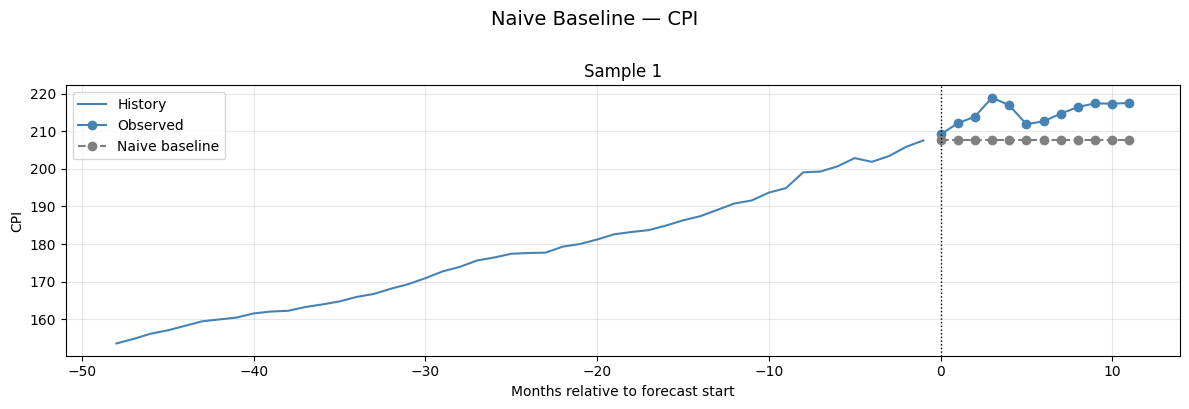

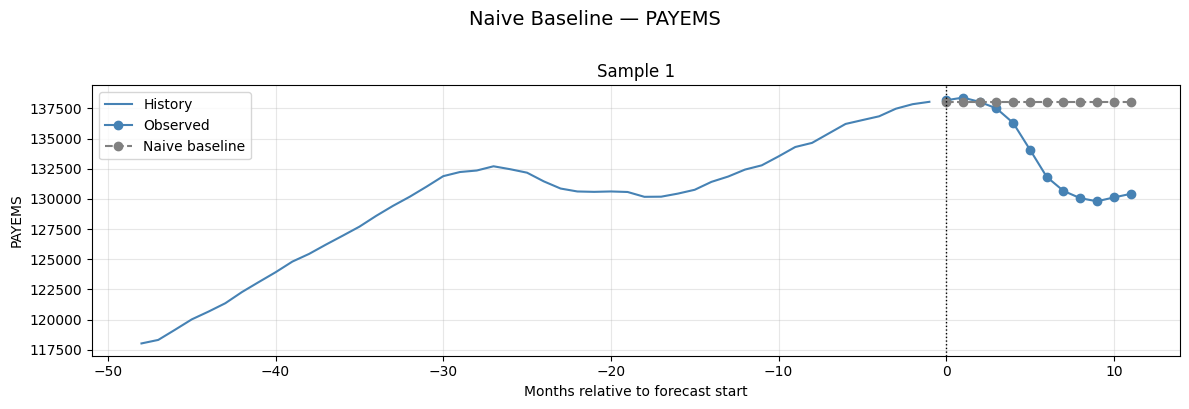

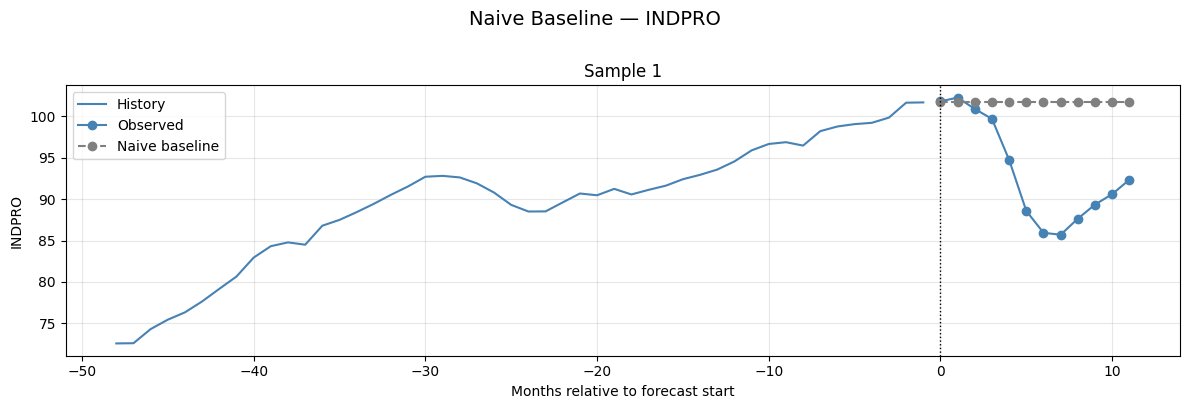

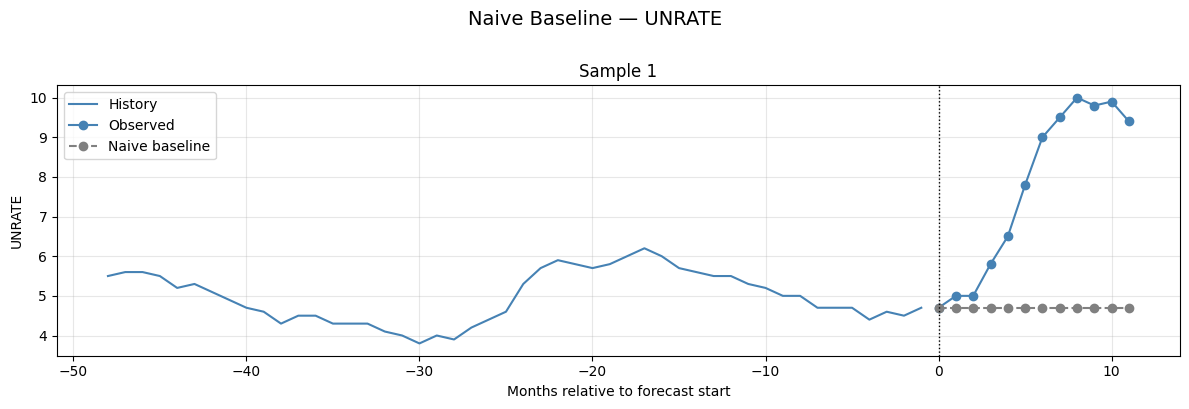

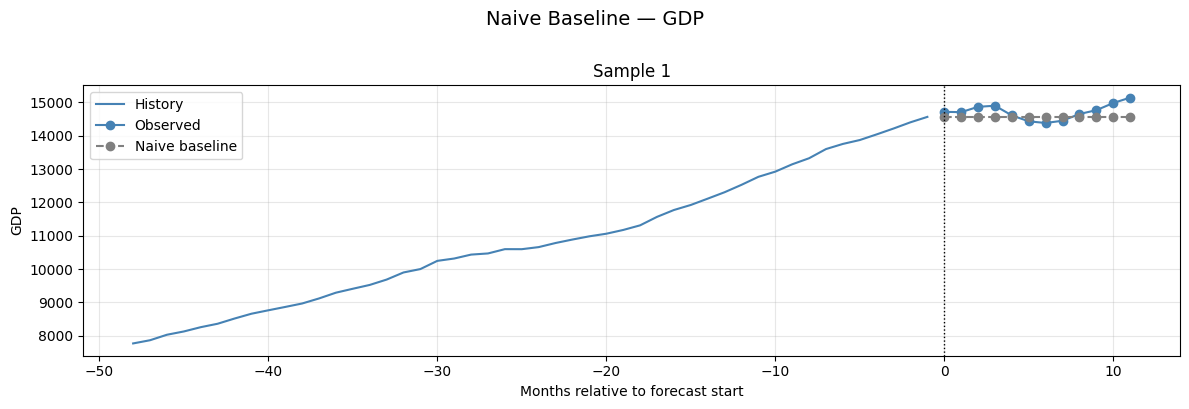

In [45]:
# get encoder history from multi-series validation data
raw_out = best_ms_tft.predict(val_dl_ms, mode='raw', return_x=True)
raw_x   = raw_out.x

n_plots = 4
for target in lag_vars:
    # not just all macro - to leverage tft architecture
    sample_idxs = [i for i, s in enumerate(ms_idx['series_id']) if s == target][:n_plots]

    n = len(sample_idxs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    for plot_i, si in enumerate(sample_idxs):
        ax = axes[plot_i]
        history = raw_x['encoder_target'][si].numpy()
        obs     = ms_acts[si].numpy()
        pred    = ms_baseline[si].numpy()

        n_hist = len(history)
        ax.plot(range(-n_hist, 0), history, color='steelblue', label='History')
        ax.plot(range(len(obs)), obs, marker='o', color='steelblue', label='Observed')
        ax.plot(range(len(pred)), pred, marker='o', linestyle='--', color='gray', label='Naive baseline')
        ax.axvline(0, color='black', linestyle=':', linewidth=1)
        ax.set_title(f'Sample {plot_i + 1}')
        ax.set_xlabel('Months relative to forecast start')
        ax.set_ylabel(target)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Naive Baseline — {target}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


=== TFT Predictions for: CPI ===


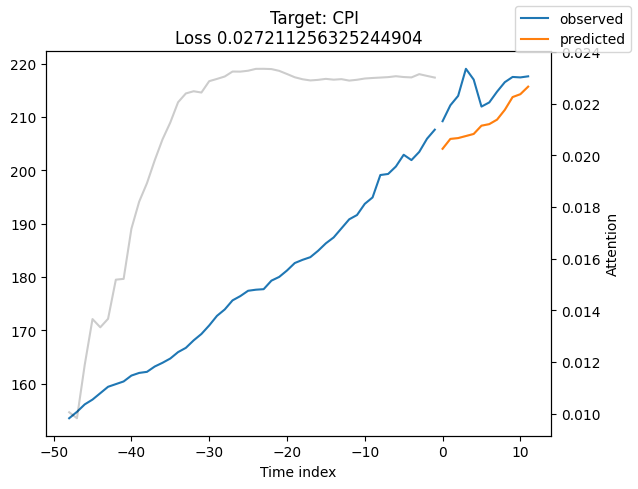

=== TFT Predictions for: PAYEMS ===


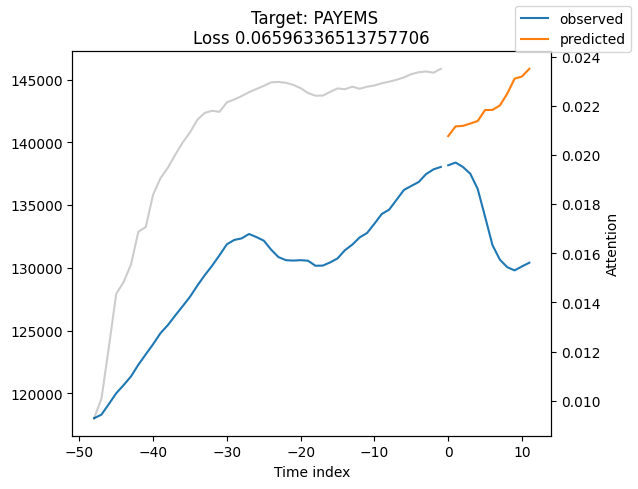

=== TFT Predictions for: INDPRO ===


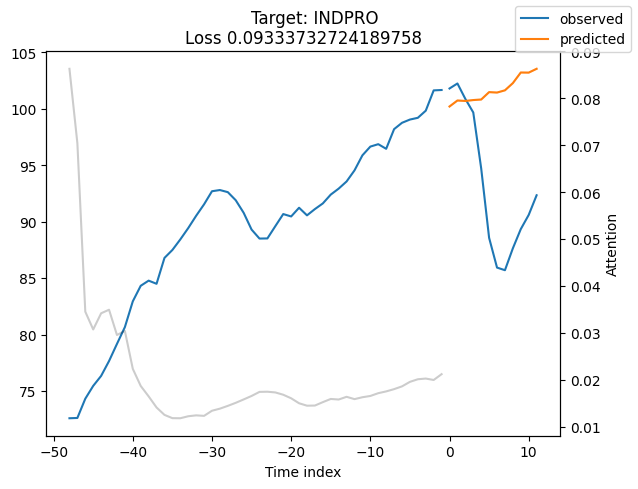

=== TFT Predictions for: UNRATE ===


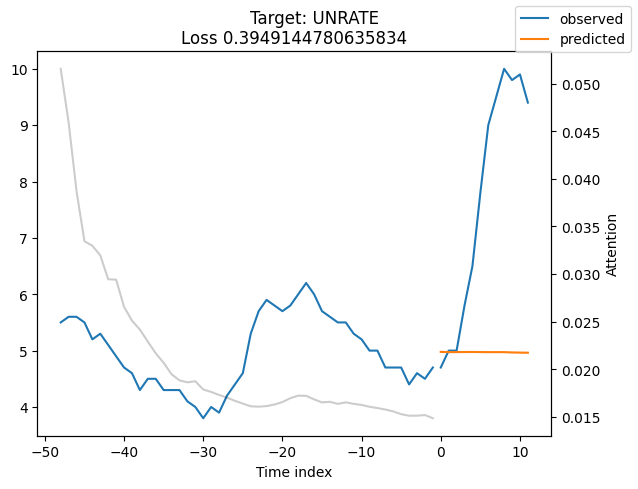

=== TFT Predictions for: GDP ===


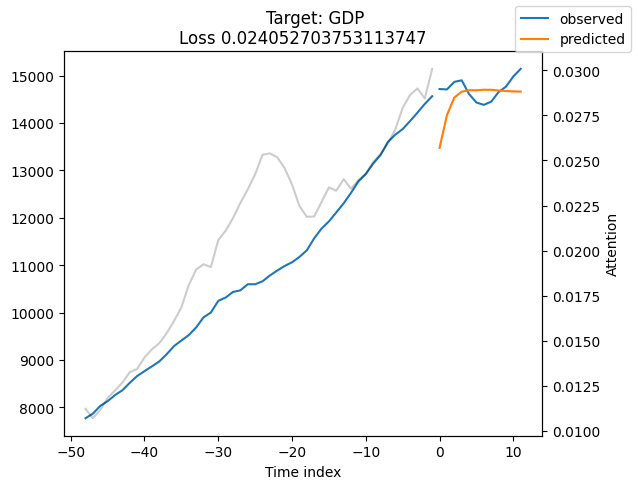

In [46]:
raw_preds_out = best_ms_tft.predict(val_dl_ms, mode='raw', return_x=True)
raw_x_tft     = raw_preds_out.x
raw_preds_tft = raw_preds_out.output

n_plots = 4
for target in lag_vars:
    print(f'=== TFT Predictions for: {target} ===')
    sample_idxs = [i for i, s in enumerate(ms_idx['series_id']) if s == target][:n_plots]
    for si in sample_idxs:
        best_ms_tft.plot_prediction(raw_x_tft, raw_preds_tft, idx=si, add_loss_to_title=True)
        plt.suptitle(f'Target: {target}', y=1.01)
        plt.show()


**Interpretation**: These plots dont look super intuitive, because the method `plot_predictions` labels show attention, but on the left side you see the actual value, in our case, CPI, PAYEMS, INDPRO, UNRATE. 

To compare the results for the Naive Baseline and the TFT, i will plot the results:

In [47]:
losses = pd.DataFrame({
    "Naive": [round(naive_loss[target], ndigits=4) for target in lag_vars],
    "TFT": [round(tft_loss[target], ndigits=4) for target in lag_vars],
}, index=lag_vars)
print(losses)

         Naive     TFT
CPI     0.0348  0.0272
PAYEMS  0.0323  0.0660
INDPRO  0.0891  0.0933
UNRATE  0.4382  0.3949
GDP     0.0152  0.0241


**Before adding Metadata**: the naive is better for all except for CPI for now, let's see how this changes with more metadata

**After adding Metadata (of target var)**: Now the tft is better for both indpro, but a bit worse for cpi.

**After adding Metadata for all vars**: Now the tft is better for cpi, but a lot worse for the others??

**After normalising, pivoting data and combining into one trainer**: tft is only better for cpi, (but tft performs better for indpro, and for payems than before, worse for unrate)

**Addded GDP, quarterly**: now cannot compare numbers to before really, but TFT better than Naive in CPI, UNRATE here